
# FireRisk AI — Etapa 1 corrigida
## Entendimento, preparação e análise exploratória dos dados

### Objetivo

O objetivo desta etapa é preparar uma base consistente para um modelo de classificação capaz de estimar se haverá pelo menos um foco de queimada em determinado **município e dia**.

A variável alvo é `fire_occurrence`:

- `0`: não houve foco de queimada;
- `1`: houve pelo menos um foco de queimada.

Esta versão incorpora as correções solicitadas na primeira avaliação: auditoria explícita de ausência total de clima, controle físico de qualidade da radiação, nomes das classes MapBiomas, histogramas, análise geográfica e metas para os KPIs.


In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# Funciona quando o notebook é aberto pela raiz do repo ou pela pasta notebooks/.
def localizar_raiz_projeto():
    cwd = Path.cwd().resolve()
    for candidato in [cwd, cwd.parent]:
        if (candidato / 'data' / 'processed' / 'dataset_ml.csv').exists():
            return candidato
    raise FileNotFoundError('Não foi possível localizar data/processed/dataset_ml.csv')

ROOT = localizar_raiz_projeto()
DATA_PATH = ROOT / 'data' / 'processed' / 'dataset_ml.csv'
QUALITY_DIR = ROOT / 'reports' / 'qualidade'
FIG_DIR = ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Raiz do projeto:', ROOT)


Raiz do projeto: /mnt/data/projeto_final_queimadas_etapa1_corrigido



## 1. Carregamento da base processada

A base já foi consolidada pelo script `src/consolidar_base.py`. A janela analisada é de **01/01/2025 a 12/02/2025**, período comum entre a base meteorológica e a base de queimadas de 2025.


In [2]:

df = pd.read_csv(DATA_PATH, parse_dates=['data'])

print('Dimensão final:', df.shape)
print('Período:', df['data'].min().date(), 'até', df['data'].max().date())
print('Municípios:', df['id_municipio'].nunique())
print('Observações positivas:', int(df['fire_occurrence'].sum()))
print('Taxa positiva:', f"{df['fire_occurrence'].mean()*100:.2f}%")

df.head()


Dimensão final: (18855, 52)
Período: 2025-01-01 até 2025-02-12
Municípios: 457
Observações positivas: 2885
Taxa positiva: 15.30%


,data,id_municipio,id_municipio_nome,sigla_uf,sigla_uf_nome,regiao,precipitacao_diaria,pressao_media,radiacao_global_diaria,temperatura_media,temperatura_maxima,temperatura_minima,umidade_media,rajada_maxima,vento_medio,latitude,longitude,altitude,n_estacoes,mb_area_id0_sem_legenda,mb_area_formacao_florestal,mb_area_formacao_savanica,mb_area_mangue,mb_area_silvicultura,mb_area_campo_alagado_area_pantanosa,mb_area_formacao_campestre,mb_area_outras_formacoes_nao_florestais,mb_area_pastagem,mb_area_cana,mb_area_mosaico_de_usos,mb_area_praia_duna_areal,mb_area_area_urbanizada,mb_area_outras_areas_nao_vegetadas,mb_area_afloramento_rochoso,mb_area_mineracao,mb_area_aquicultura,mb_area_apicum,mb_area_rio_lago_oceano,mb_area_soja,mb_area_arroz_beta,mb_area_outras_lavouras_temporarias,mb_area_cafe,mb_area_citrus,mb_area_outras_lavouras_perenes,mb_area_restinga_arborizada,mb_area_restinga_herbacea,mb_area_algodao_beta,mes,dia_do_ano,dia_semana,focos_queimada,fire_occurrence
0,2025-01-01,1100049,Cacoal,RO,Rondônia,Norte,0.200,988.087,"11,785.600",25.425,28.100,23.200,82.917,7.700,1.858,-11.446,-61.434,183.530,1,0.000,"1,415.138",23.900,0.000,0.000,1.084,5.291,0.000,"2,292.184",0.000,0.000,0.000,26.546,0.000,0.000,0.000,0.000,0.000,11.325,14.171,0.000,3.292,0.000,0.000,0.000,0.000,0.000,0.000,1,1,2,0,0
1,2025-01-01,1100205,Porto Velho,RO,Rondônia,Norte,0.000,998.500,"2,541.100",26.233,27.400,25.500,82.000,NaN,NaN,-8.794,-63.846,86.700,1,0.011,"22,316.671",29.123,0.000,0.000,118.618,443.801,0.000,"9,841.033",0.000,0.000,0.000,130.529,0.000,0.000,25.440,0.000,0.000,997.147,79.714,0.000,95.354,0.000,0.000,0.000,0.000,0.000,0.000,1,1,2,0,0
2,2025-01-01,1100304,Vilhena,RO,Rondônia,Norte,0.000,944.579,"16,267.100",24.058,28.900,22.200,83.875,NaN,NaN,-12.735,-60.158,583.300,1,0.000,"8,853.127",777.086,0.000,7.659,13.790,165.539,0.000,"1,327.090",0.000,18.713,0.000,42.775,25.972,0.000,0.820,0.000,0.000,6.343,405.616,0.000,54.663,0.000,0.000,0.000,0.000,0.000,0.000,1,1,2,0,0
3,2025-01-01,1200252,Epitaciolândia,AC,Acre,Norte,NaN,983.433,"13,966.900",25.863,31.400,23.600,NaN,7.400,0.704,-11.024,-68.735,224.500,1,0.001,777.859,0.184,0.000,0.000,0.105,4.396,0.000,860.539,0.000,0.000,0.000,3.213,0.000,0.000,0.000,0.000,0.000,3.970,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1,1,2,0,0
4,2025-01-01,1200302,Feijó,AC,Acre,Norte,0.000,990.746,NaN,25.375,29.400,23.400,79.615,6.900,1.337,-8.143,-70.344,157.170,1,0.004,"26,532.242",0.813,0.000,0.000,9.813,36.056,0.000,"1,296.616",0.000,0.000,0.000,4.179,0.000,0.000,0.000,0.000,0.000,83.862,0.000,0.000,0.011,0.000,0.000,0.000,0.000,0.000,0.000,1,1,2,2,1



## 2. Distribuição da variável alvo

Como a classe positiva é menor que a negativa, a acurácia não será suficiente para avaliar os modelos. Na Etapa 2 serão usados principalmente Recall, Precision, F1-score e ROC-AUC.


,quantidade,percentual
fire_occurrence,,
0,15970,84.700
1,2885,15.300


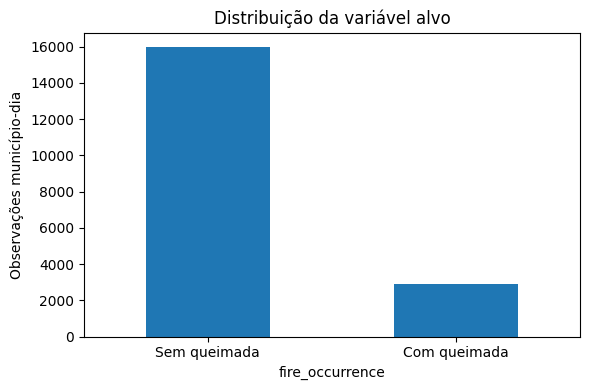

In [3]:

target_summary = pd.DataFrame({
    'quantidade': df['fire_occurrence'].value_counts().sort_index(),
    'percentual': (df['fire_occurrence'].value_counts(normalize=True).sort_index()*100).round(2)
})
display(target_summary)

plt.figure(figsize=(6,4))
df['fire_occurrence'].value_counts().sort_index().plot(kind='bar')
plt.xticks([0,1], ['Sem queimada', 'Com queimada'], rotation=0)
plt.ylabel('Observações município-dia')
plt.title('Distribuição da variável alvo')
plt.tight_layout()
plt.savefig(FIG_DIR / 'distribuicao_alvo.png', dpi=150)
plt.show()



## 3. Auditoria de cobertura climática

Na versão anterior, a análise de faltantes mostrava apenas a porcentagem por coluna. Isso escondia um problema importante: algumas linhas não tinham **nenhuma informação meteorológica**.

Nesta versão, a cobertura é analisada por linha e por município antes do filtro final.


In [4]:

coverage = pd.read_csv(QUALITY_DIR / 'cobertura_climatica_municipios.csv')
excluded = pd.read_csv(QUALITY_DIR / 'municipios_excluidos_sem_clima.csv')

linhas_sem_clima = int(coverage['dias_sem_nenhum_clima'].sum())
linhas_totais_antes = int(coverage['dias_no_periodo'].sum())

print('Municípios auditados:', len(coverage))
print('Municípios com 0 dias de clima:', int(coverage['municipio_sem_clima_total'].sum()))
print('Linhas município-dia sem nenhuma variável climática:', linhas_sem_clima)
print('Percentual das linhas originais:', f'{100*linhas_sem_clima/linhas_totais_antes:.2f}%')
print('Municípios restantes na base final:', df['id_municipio'].nunique())
print('Linhas finais:', len(df))

display(excluded.head(10))


Municípios auditados: 542
Municípios com 0 dias de clima: 85
Linhas município-dia sem nenhuma variável climática: 4451
Percentual das linhas originais: 19.10%
Municípios restantes na base final: 457
Linhas finais: 18855


,id_municipio,id_municipio_nome,dias_no_periodo,dias_sem_nenhum_clima,dias_com_algum_clima,pct_dias_com_algum_clima,municipio_sem_clima_total
0,1100023,Ariquemes,43,43,0,0.000,True
1,1200203,Cruzeiro do Sul,43,43,0,0.000,True
2,1200344,Manoel Urbano,43,43,0,0.000,True
3,1200351,Marechal Thaumaturgo,43,43,0,0.000,True
4,1200393,Porto Walter,43,43,0,0.000,True
5,1300300,Autazes,43,43,0,0.000,True
6,1301407,Eirunepé,43,43,0,0.000,True
7,1302900,Maués,43,43,0,0.000,True
8,1303536,Presidente Figueiredo,43,43,0,0.000,True
9,1303569,Rio Preto da Eva,43,43,0,0.000,True


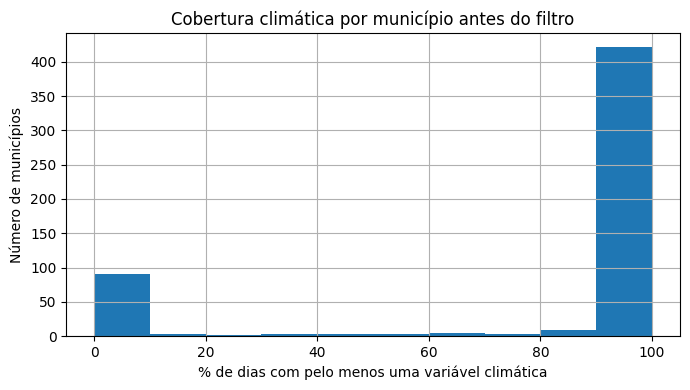

In [5]:

plt.figure(figsize=(7,4))
coverage['pct_dias_com_algum_clima'].hist(bins=10)
plt.xlabel('% de dias com pelo menos uma variável climática')
plt.ylabel('Número de municípios')
plt.title('Cobertura climática por município antes do filtro')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cobertura_climatica_municipios.png', dpi=150)
plt.show()



### Decisão de limpeza

Foram removidas todas as linhas município-dia em que as nove variáveis meteorológicas estavam simultaneamente ausentes. Com isso, os 85 municípios sem nenhum dado climático em todo o período deixam de fazer parte da base de ML.

Essa decisão reduz o risco de o modelo usar apenas latitude, longitude, altitude e MapBiomas para memorizar municípios quando o objetivo do projeto é avaliar principalmente a relação entre **condições climáticas e ocorrência de queimadas**.



## 4. Dados ausentes após a correção

Ainda existem valores ausentes em variáveis meteorológicas individuais. Eles são mantidos nesta etapa. A imputação deve ser ajustada somente no conjunto de treinamento ou dentro de uma pipeline na Etapa 2, evitando vazamento de informação.


,percentual_ausente
precipitacao_diaria,15.870
rajada_maxima,8.220
vento_medio,8.060
umidade_media,5.600
radiacao_global_diaria,3.480
temperatura_maxima,1.470
temperatura_minima,1.470
temperatura_media,1.380
pressao_media,0.420


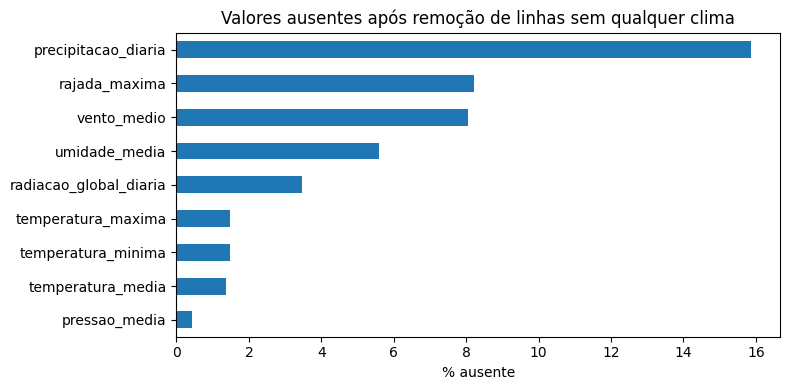

In [6]:

weather_cols = [
    'precipitacao_diaria', 'pressao_media', 'radiacao_global_diaria',
    'temperatura_media', 'temperatura_maxima', 'temperatura_minima',
    'umidade_media', 'rajada_maxima', 'vento_medio'
]

missing = (df[weather_cols].isna().mean()*100).sort_values(ascending=False).to_frame('percentual_ausente')
display(missing.round(2))

plt.figure(figsize=(8,4))
missing.sort_values('percentual_ausente')['percentual_ausente'].plot(kind='barh')
plt.xlabel('% ausente')
plt.title('Valores ausentes após remoção de linhas sem qualquer clima')
plt.tight_layout()
plt.savefig(FIG_DIR / 'missing_clima_pos_correcao.png', dpi=150)
plt.show()



## 5. Controle de qualidade físico dos dados meteorológicos

O IQR identifica valores estatisticamente extremos, mas não responde se um valor é **fisicamente possível**. Por isso, antes do IQR foram aplicadas regras básicas de consistência.

O INMET informa que os dados de estações automáticas são brutos e podem conter falhas de sensores ou comunicação. Para radiação, usamos a unidade informada pelo INMET (kJ/m² por hora) e comparamos a soma diária com a radiação extraterrestre diária calculada pela fórmula FAO-56.

Regra aplicada à radiação:

- valor diário `<= 0`: inválido para o Brasil nesse período;
- valor diário acima de 105% da radiação extraterrestre do dia/local: inválido;
- valores inválidos são convertidos para `NaN`, não tratados como extremos reais.


In [7]:

quality_rules = pd.read_csv(QUALITY_DIR / 'regras_qualidade.csv')
radiation_invalid = pd.read_csv(QUALITY_DIR / 'radiacao_invalida.csv')

display(quality_rules)
print('Registros estação-dia de radiação convertidos para NaN:', len(radiation_invalid))
display(radiation_invalid.sort_values('radiacao_global_diaria', ascending=False).head(10))


,variavel,regra,n_invalidos,acao
0,precipitacao_diaria,precipitação < 0 mm,0,convertido para NaN
1,pressao_media,pressão <= 0 hPa,0,convertido para NaN
2,umidade_media,umidade fora de 0–100%,0,convertido para NaN
3,vento_medio,vento médio < 0 m/s,0,convertido para NaN
4,rajada_maxima,rajada < 0 m/s,0,convertido para NaN
5,temperatura_maxima/minima,temperatura máxima < mínima,0,ambas convertidas para NaN
6,radiacao_global_diaria,<=0 ou >105% da radiação extraterrestre diária,45,convertido para NaN


Registros estação-dia de radiação convertidos para NaN: 45


,id_estacao,id_municipio,id_municipio_nome,data,latitude,longitude,radiacao_global_diaria,radiacao_global_mj_m2_dia_original,radiacao_extraterrestre_mj_m2_dia,motivo
4,A054,1702000,Araguaçu,2025-01-15,-12.592,-49.529,"87,895.400",87.895,40.226,radiação diária > 105% da radiação extraterres...
10,A054,1702000,Araguaçu,2025-02-04,-12.592,-49.529,"76,228.600",76.229,39.966,radiação diária > 105% da radiação extraterres...
9,A054,1702000,Araguaçu,2025-02-03,-12.592,-49.529,"75,437.300",75.437,39.990,radiação diária > 105% da radiação extraterres...
3,A054,1702000,Araguaçu,2025-01-14,-12.592,-49.529,"73,925.900",73.926,40.230,radiação diária > 105% da radiação extraterres...
2,A054,1702000,Araguaçu,2025-01-13,-12.592,-49.529,"67,755.300",67.755,40.233,radiação diária > 105% da radiação extraterres...
39,A715,3550209,São Miguel Arcanjo,2025-01-24,-23.852,-48.165,"61,460.500",61.461,41.985,radiação diária > 105% da radiação extraterres...
7,A054,1702000,Araguaçu,2025-02-01,-12.592,-49.529,"58,814.900",58.815,40.034,radiação diária > 105% da radiação extraterres...
1,A054,1702000,Araguaçu,2025-01-12,-12.592,-49.529,"58,113.500",58.114,40.235,radiação diária > 105% da radiação extraterres...
8,A054,1702000,Araguaçu,2025-02-02,-12.592,-49.529,"58,014.700",58.015,40.013,radiação diária > 105% da radiação extraterres...
40,A715,3550209,São Miguel Arcanjo,2025-01-25,-23.852,-48.165,"54,820.700",54.821,41.920,radiação diária > 105% da radiação extraterres...



A maior anomalia encontrada era uma radiação diária próxima de **87,9 MJ/m²**, enquanto o limite extraterrestre calculado para aquele local e dia era aproximadamente 40 MJ/m². Também existiam 22 registros estação-dia com soma diária igual a zero. Esses casos foram tratados como problemas de qualidade, e não como eventos climáticos extremos.



## 6. Estatísticas descritivas


In [8]:

display(df[weather_cols + ['focos_queimada','fire_occurrence']].describe().T)


,count,mean,std,min,25%,50%,75%,max
precipitacao_diaria,"15,862.000",5.761,12.539,0.000,0.000,0.200,5.400,171.800
pressao_media,"18,775.000",962.686,36.558,822.992,936.419,965.825,993.417,"1,017.938"
radiacao_global_diaria,"18,199.000","19,514.656","6,866.885",0.100,"14,950.350","20,155.700","24,772.650","44,466.100"
temperatura_media,"18,595.000",25.226,2.631,13.137,23.688,25.392,26.867,36.208
temperatura_maxima,"18,577.000",31.178,3.159,15.000,29.200,31.400,33.300,43.800
temperatura_minima,"18,577.000",21.205,2.725,7.300,19.600,21.500,23.000,33.300
umidade_media,"17,799.000",75.901,11.092,7.000,69.333,77.286,83.792,100.000
rajada_maxima,"17,306.000",9.118,2.895,0.000,7.200,8.800,10.600,35.600
vento_medio,"17,335.000",1.773,1.014,0.000,1.109,1.596,2.267,10.204
focos_queimada,"18,855.000",0.719,5.099,0.000,0.000,0.000,0.000,352.000



## 7. Outliers estatísticos — método IQR

Depois do controle físico, o IQR é usado apenas para **sinalizar observações incomuns**. Elas não são removidas automaticamente, porque chuva intensa, temperatura alta ou rajadas fortes podem ser fenômenos reais e relevantes para o problema.


In [9]:

outlier_rows=[]
for col in weather_cols:
    s=df[col].dropna()
    q1=s.quantile(.25)
    q3=s.quantile(.75)
    iqr=q3-q1
    lo=q1-1.5*iqr
    hi=q3+1.5*iqr
    n=((s<lo)|(s>hi)).sum()
    outlier_rows.append({
        'variavel':col,'q1':q1,'q3':q3,'limite_inferior_iqr':lo,
        'limite_superior_iqr':hi,'n_outliers_iqr':int(n),'pct_outliers_iqr':100*n/len(s)
    })
outliers=pd.DataFrame(outlier_rows).sort_values('pct_outliers_iqr',ascending=False)
display(outliers.round(2))


,variavel,q1,q3,limite_inferior_iqr,limite_superior_iqr,n_outliers_iqr,pct_outliers_iqr
0,precipitacao_diaria,0.000,5.400,-8.100,13.500,2258,14.240
8,vento_medio,1.110,2.270,-0.630,4.010,525,3.030
7,rajada_maxima,7.200,10.600,2.100,15.700,523,3.020
5,temperatura_minima,19.600,23.000,14.500,28.100,498,2.680
3,temperatura_media,23.690,26.870,18.920,31.640,485,2.610
6,umidade_media,69.330,83.790,47.650,105.480,291,1.630
4,temperatura_maxima,29.200,33.300,23.050,39.450,263,1.420
1,pressao_media,936.420,993.420,850.920,"1,078.910",129,0.690
2,radiacao_global_diaria,"14,950.350","24,772.650",216.900,"39,506.100",73,0.400



## 8. Histogramas das features meteorológicas

Os histogramas ajudam a visualizar assimetria, concentração em zero, caudas e possíveis transformações que podem ser úteis na modelagem.


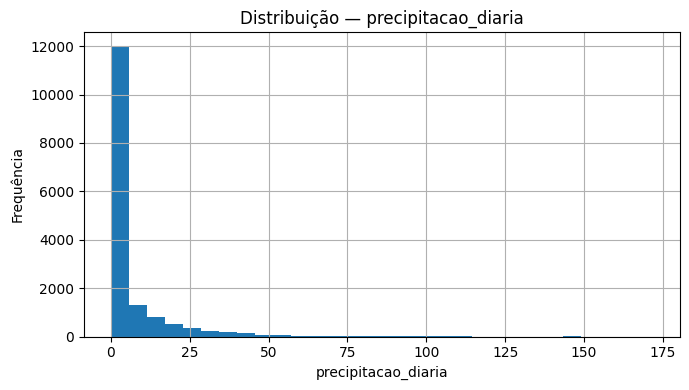

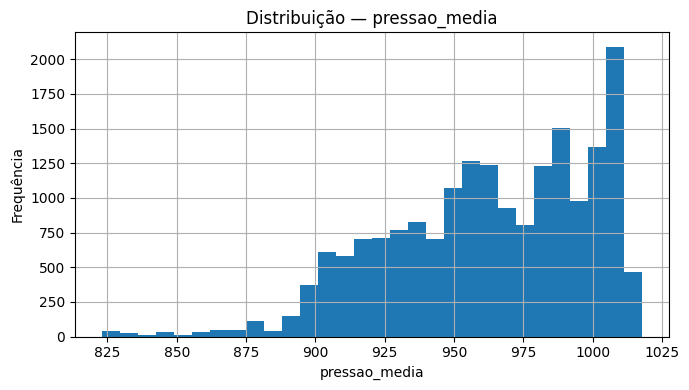

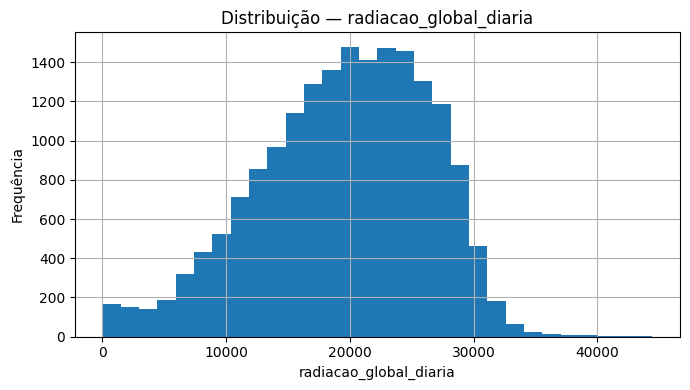

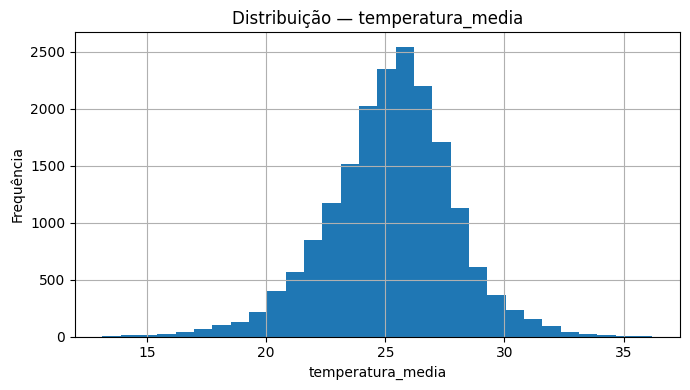

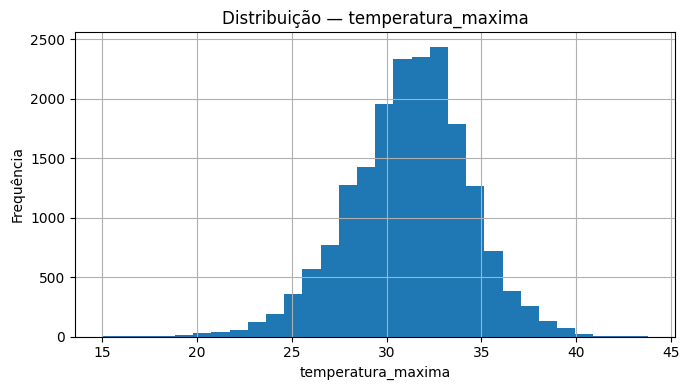

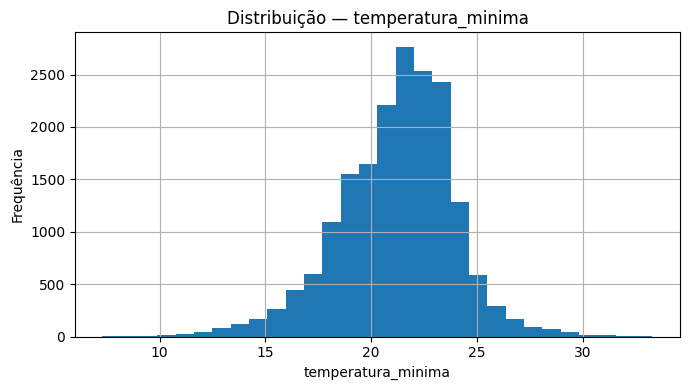

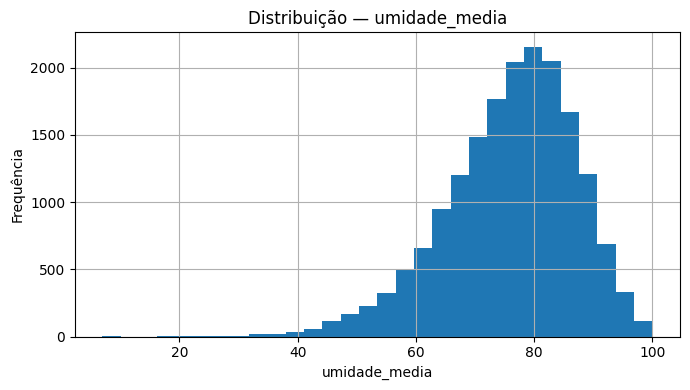

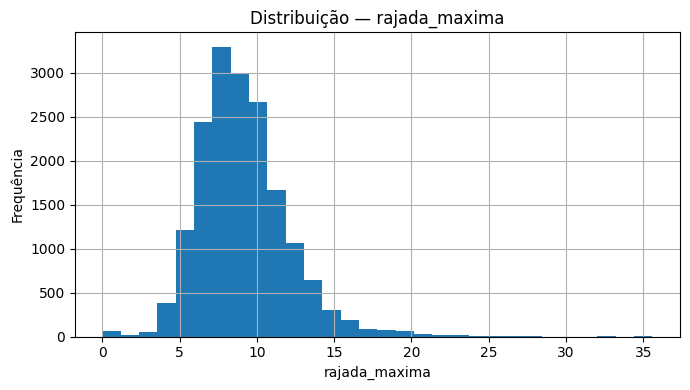

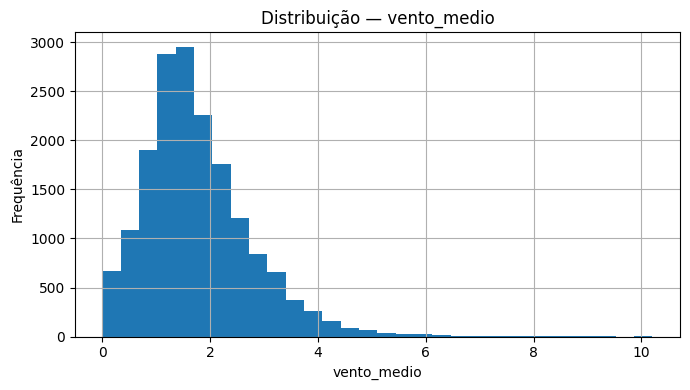

In [10]:

for col in weather_cols:
    plt.figure(figsize=(7,4))
    df[col].dropna().hist(bins=30)
    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.title(f'Distribuição — {col}')
    plt.tight_layout()
    if col in ['precipitacao_diaria','temperatura_maxima','umidade_media','radiacao_global_diaria']:
        plt.savefig(FIG_DIR / f'hist_{col}.png', dpi=150)
    plt.show()



## 9. Correlação das variáveis meteorológicas com o alvo

Foi utilizada correlação de Spearman por ser menos sensível a distribuições assimétricas e relações monotônicas não lineares.


,correlacao_com_alvo
temperatura_maxima,0.268
temperatura_media,0.249
umidade_media,-0.230
precipitacao_diaria,-0.181
radiacao_global_diaria,0.169
temperatura_minima,0.125
pressao_media,0.083
vento_medio,0.052
rajada_maxima,0.016


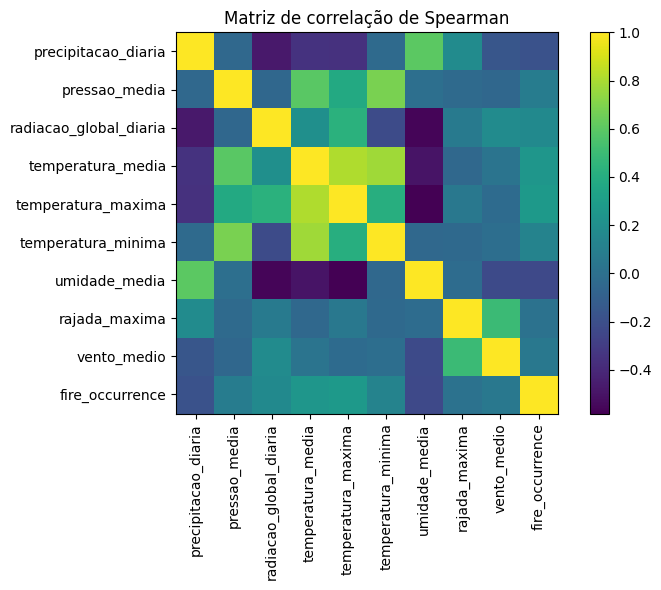

In [11]:

corr_cols=weather_cols+['fire_occurrence']
corr=df[corr_cols].corr(method='spearman')

target_corr=corr['fire_occurrence'].drop('fire_occurrence')
target_corr=target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
display(target_corr.to_frame('correlacao_com_alvo').round(3))

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.xticks(range(len(corr_cols)),corr_cols,rotation=90)
plt.yticks(range(len(corr_cols)),corr_cols)
plt.colorbar()
plt.title('Matriz de correlação de Spearman')
plt.tight_layout()
plt.savefig(FIG_DIR/'correlacao_spearman.png',dpi=150)
plt.show()



As associações mais fortes com a ocorrência de queimadas são observadas em temperatura máxima e média (positivas), e umidade e precipitação (negativas). Essas relações ajudam a orientar a modelagem, mas não provam causalidade.



## 10. MapBiomas — cobertura e uso do solo

As classes agora aparecem com nomes legíveis baseados na legenda oficial da Coleção 7 do MapBiomas. Como os valores são constantes por município, para esta análise cada município é contado apenas uma vez.


,area_total_km2
mb_area_formacao_florestal,"1,189,878.900"
mb_area_pastagem,"344,294.000"
mb_area_formacao_savanica,"252,173.200"
mb_area_formacao_campestre,"162,255.600"
mb_area_soja,"142,112.700"
mb_area_mosaico_de_usos,"76,888.200"
mb_area_rio_lago_oceano,"46,592.200"
mb_area_campo_alagado_area_pantanosa,"32,976.400"
mb_area_silvicultura,"18,774.100"
mb_area_outras_lavouras_temporarias,"17,082.500"


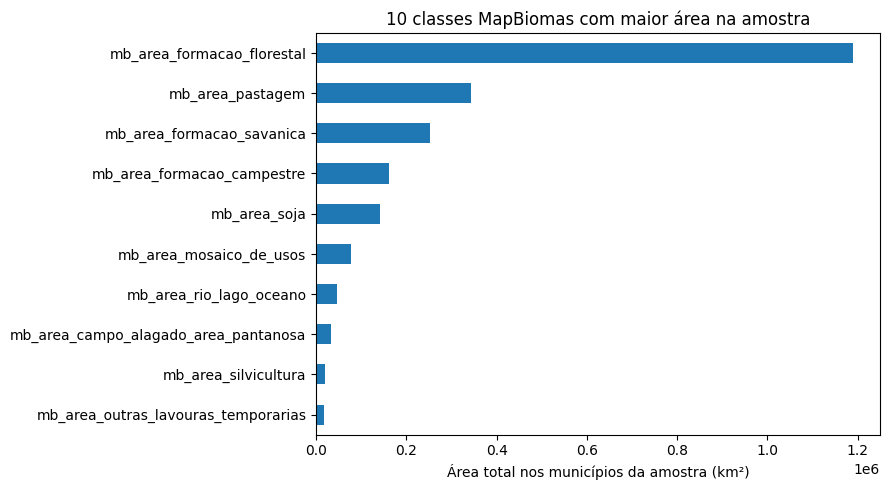

In [12]:

map_cols=[c for c in df.columns if c.startswith('mb_area_')]
municipios_map=df[['id_municipio']+map_cols].drop_duplicates('id_municipio')
map_totals=municipios_map[map_cols].sum().sort_values(ascending=False)

display(map_totals.head(12).to_frame('area_total_km2').round(1))

plt.figure(figsize=(9,5))
map_totals.head(10).sort_values().plot(kind='barh')
plt.xlabel('Área total nos municípios da amostra (km²)')
plt.title('10 classes MapBiomas com maior área na amostra')
plt.tight_layout()
plt.savefig(FIG_DIR/'mapbiomas_top_classes.png',dpi=150)
plt.show()



A formação florestal ocupa a maior área total entre os municípios da amostra, seguida por pastagem, formação savânica, formação campestre e soja. Essas variáveis podem ajudar o modelo a diferenciar contextos estruturais de uso e cobertura do solo.



## 11. Análise geográfica — região e UF

Como incêndios e clima variam geograficamente, é importante observar se a ocorrência está concentrada em algumas regiões. Isso também prepara a análise de viés/robustez das próximas etapas.


,observacoes,municipios,dias_com_queimada,taxa_queimada,taxa_queimada_pct
regiao,,,,,
Nordeste,4121,102,947,0.230,22.980
Centro-Oeste,3121,75,633,0.200,20.280
Norte,2631,64,453,0.170,17.220
Sul,3514,86,346,0.100,9.850
Sudeste,5468,130,506,0.090,9.250


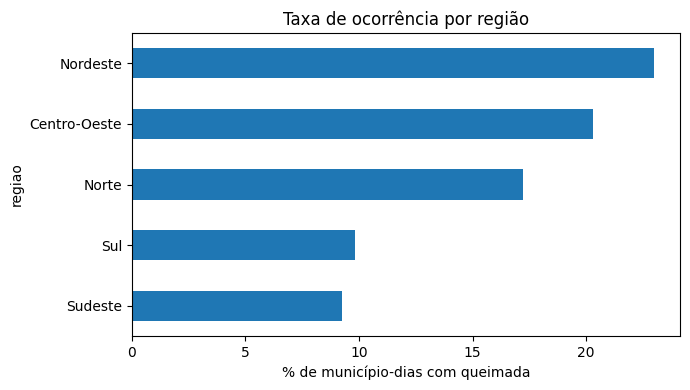

In [13]:

region_summary=(
    df.groupby('regiao')
      .agg(observacoes=('fire_occurrence','size'),
           municipios=('id_municipio','nunique'),
           dias_com_queimada=('fire_occurrence','sum'),
           taxa_queimada=('fire_occurrence','mean'))
      .sort_values('taxa_queimada',ascending=False)
)
region_summary['taxa_queimada_pct']=region_summary['taxa_queimada']*100
display(region_summary.round(2))

plt.figure(figsize=(7,4))
region_summary['taxa_queimada_pct'].sort_values().plot(kind='barh')
plt.xlabel('% de município-dias com queimada')
plt.title('Taxa de ocorrência por região')
plt.tight_layout()
plt.savefig(FIG_DIR/'taxa_queimada_regiao.png',dpi=150)
plt.show()


,sigla_uf,sigla_uf_nome,observacoes,municipios,dias_com_queimada,taxa_queimada,taxa_queimada_pct
5,CE,Ceará,320,8,113,0.350,35.310
11,MS,Mato Grosso do Sul,1051,26,332,0.320,31.590
15,PE,Pernambuco,430,10,126,0.290,29.300
1,AL,Alagoas,248,6,67,0.270,27.020
4,BA,Bahia,1169,29,280,0.240,23.950
13,PA,Pará,943,24,224,0.240,23.750
9,MA,Maranhão,553,15,121,0.220,21.880
14,PB,Paraíba,301,7,65,0.220,21.590
12,MT,Mato Grosso,1002,24,192,0.190,19.160
16,PI,Piauí,628,16,118,0.190,18.790


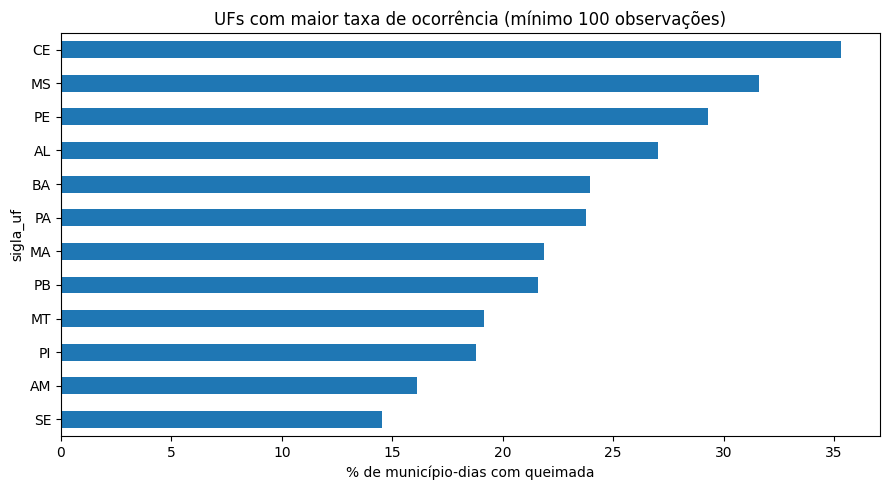

In [14]:

uf_summary=(
    df.groupby(['sigla_uf','sigla_uf_nome'])
      .agg(observacoes=('fire_occurrence','size'),
           municipios=('id_municipio','nunique'),
           dias_com_queimada=('fire_occurrence','sum'),
           taxa_queimada=('fire_occurrence','mean'))
      .reset_index()
)
uf_summary['taxa_queimada_pct']=uf_summary['taxa_queimada']*100

# Para a comparação gráfica evitamos UFs com amostras muito pequenas.
uf_plot=uf_summary[uf_summary['observacoes']>=100].sort_values('taxa_queimada_pct',ascending=False)
display(uf_plot.head(12).round(2))

plt.figure(figsize=(9,5))
uf_plot.head(12).sort_values('taxa_queimada_pct').set_index('sigla_uf')['taxa_queimada_pct'].plot(kind='barh')
plt.xlabel('% de município-dias com queimada')
plt.title('UFs com maior taxa de ocorrência (mínimo 100 observações)')
plt.tight_layout()
plt.savefig(FIG_DIR/'taxa_queimada_uf.png',dpi=150)
plt.show()



Na janela analisada, Nordeste e Centro-Oeste apresentam as maiores taxas de município-dias com queimadas. Esse padrão deve ser interpretado junto com a curta janela temporal e a cobertura desigual de estações; ele não representa uma taxa anual do Brasil.



## 12. Teste de hipótese

### Premissa de negócio

Dias com ocorrência de queimadas apresentam umidade relativa média menor.

- **H0:** a distribuição da umidade em dias com queimada não é menor do que em dias sem queimada.
- **H1:** a distribuição da umidade em dias com queimada é menor.

Foi usado o teste **Mann–Whitney U unilateral**, com nível de significância de 5%.


Média com queimada: 70.08
Média sem queimada: 76.96
Mediana com queimada: 71.67
Mediana sem queimada: 78.42
U: 13041652.0
p-valor: 2.0558985762019714e-206
Conclusão: rejeitamos H0


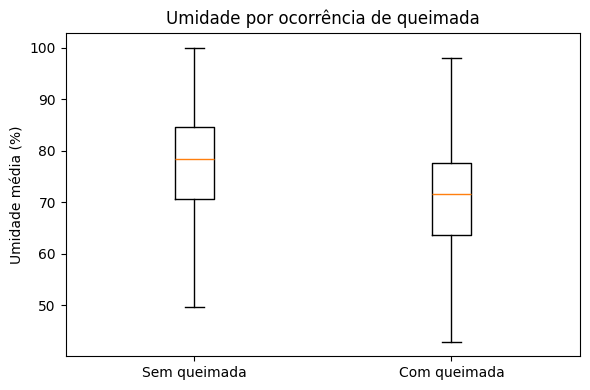

In [15]:

humidity_fire=df.loc[df['fire_occurrence']==1,'umidade_media'].dropna()
humidity_no_fire=df.loc[df['fire_occurrence']==0,'umidade_media'].dropna()

u_stat,p_value=mannwhitneyu(humidity_fire,humidity_no_fire,alternative='less')

print('Média com queimada:', round(humidity_fire.mean(),2))
print('Média sem queimada:', round(humidity_no_fire.mean(),2))
print('Mediana com queimada:', round(humidity_fire.median(),2))
print('Mediana sem queimada:', round(humidity_no_fire.median(),2))
print('U:', u_stat)
print('p-valor:', p_value)
print('Conclusão:', 'rejeitamos H0' if p_value < 0.05 else 'não rejeitamos H0')

plt.figure(figsize=(6,4))
plt.boxplot([humidity_no_fire,humidity_fire],tick_labels=['Sem queimada','Com queimada'],showfliers=False)
plt.ylabel('Umidade média (%)')
plt.title('Umidade por ocorrência de queimada')
plt.tight_layout()
plt.savefig(FIG_DIR/'umidade_por_alvo.png',dpi=150)
plt.show()



O p-valor é muito menor que 0,05. Portanto, rejeitamos H0 e encontramos evidência de que a umidade é menor nos dias com ocorrência de queimadas na amostra. A média ficou perto de 70,08% nos dias com queimada e 76,96% nos dias sem queimada.

Esse resultado valida a premissa estatística, mas não demonstra que a baixa umidade, sozinha, cause a ocorrência de queimadas.



## 13. KPIs e metas para a Etapa 2

Para evitar avaliar o modelo apenas depois de ver os resultados, foram definidos critérios de sucesso antes da nova modelagem.

| KPI | Meta | Motivo |
|---|---:|---|
| Recall positivo | **≥ 0,70** | reduzir eventos reais não sinalizados |
| F1-score | **≥ 0,40** | equilibrar Recall e Precision |
| Precision | **≥ 0,30** | controlar excesso de falsos alertas |
| ROC-AUC | **≥ 0,75** | avaliar separação global das classes |
| False Negative Rate | **≤ 0,30** | limite operacional de eventos perdidos |
| Acurácia | monitorada | não será usada isoladamente devido ao desbalanceamento |

As metas poderão ser ajustadas quando houver valores reais para o custo de falsos positivos e falsos negativos.



## 14. Conclusão da Etapa 1 corrigida

Nesta revisão, a principal correção foi tornar explícita a qualidade da cobertura meteorológica. Antes do filtro, 4.451 linhas não possuíam nenhuma variável climática e 85 municípios estavam sem clima durante todo o período. Essas linhas foram removidas da base de ML, resultando em **18.855 observações e 457 municípios**.

Também foi separado o conceito de **outlier estatístico** do conceito de **valor fisicamente inválido**. Na radiação solar, 45 registros estação-dia foram convertidos para ausentes depois da comparação com um limite físico calculado pela radiação extraterrestre diária.

O MapBiomas passou a ter nomes de classes interpretáveis no próprio dataset e no dicionário. Além disso, foram incluídos histogramas, análise das classes de cobertura do solo e recortes por região e UF.

A variável alvo continua desbalanceada, com aproximadamente **15,3%** de dias positivos. O teste de hipótese indica que a umidade é significativamente menor em dias com queimadas. Temperatura, umidade e precipitação também apresentam as associações meteorológicas mais relevantes com o alvo.

Com essas correções, a base está mais adequada para a Etapa 2. A modelagem deverá manter a imputação dentro da pipeline e também avaliar robustez geográfica, porque latitude, longitude e MapBiomas são constantes por município.
